In [17]:
import json
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


## Load data files

In [18]:
RE_DATA_ROOT = Path("../data/red_eclipse")
all_files = glob.glob(str(RE_DATA_ROOT / "**" / "*.json"), recursive=True)
game_files = [
    f for f in all_files
    if "users" not in f and Path(f).name != "sessions.json"
]

test_files = game_files[:5]
selected_files = test_files

for file_path in selected_files:
    with open(file_path) as file:
        game = json.load(file)
    n_mouse = sum(1 for e in game["events"] if e.get("type") == "MouseEvent")
    print(f"userId={game['userId']}, gameId={game['id']}, mouseEvents={n_mouse}, file={Path(file_path).name}")


userId=42, gameId=33, mouseEvents=6209, file=game-20130219-164243.json
userId=30, gameId=135, mouseEvents=7544, file=game-20130225-152939.json
userId=36, gameId=210, mouseEvents=6153, file=game-20130301-161800.json
userId=5, gameId=359, mouseEvents=4650, file=game-20131207-143426.json
userId=3, gameId=67, mouseEvents=5332, file=game-20130221-094036.json


## Mouse trajectory preview


userId=42, gameId=33, events=6209


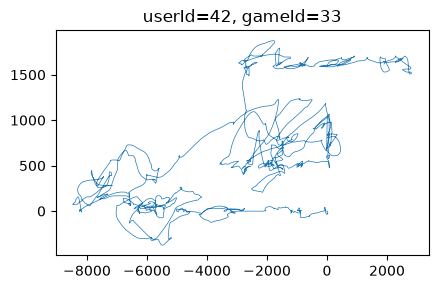


userId=30, gameId=135, events=7544


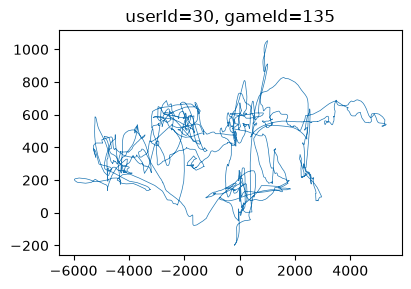


userId=36, gameId=210, events=6153


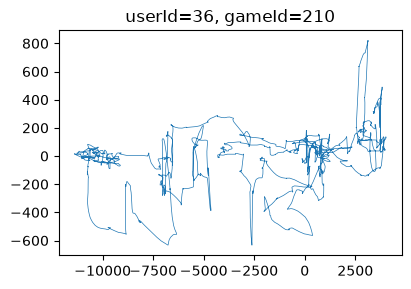


userId=5, gameId=359, events=4650


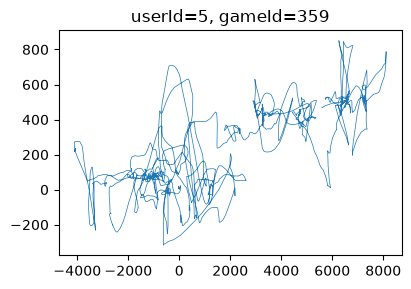


userId=3, gameId=67, events=5332


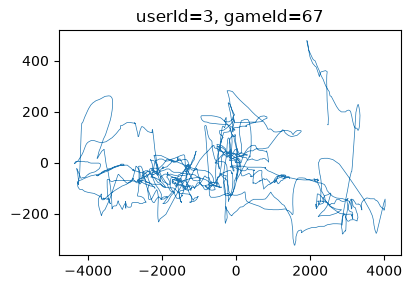

In [19]:
for i, file_path in enumerate(selected_files):
    with open(file_path) as f:
        game_data = json.load(f)

    mouse_events = [
        event for event in game_data["events"]
        if event.get("type") == "MouseEvent"
    ]
    user_id = game_data.get("userId")
    game_id = game_data.get("id")

    df = pd.DataFrame(mouse_events)
    df["trajectory_x"] = df["dx"].cumsum()
    df["trajectory_y"] = df["dy"].cumsum()

    print(f"\nuserId={user_id}, gameId={game_id}, events={len(df)}")
    # print(df[["time", "dx", "dy", "trajectory_x", "trajectory_y"]].head())

    plt.figure(figsize=(20, 3))
    
    plt.subplot(1, 5, i+1)
    plt.plot(df["trajectory_x"], df["trajectory_y"], linewidth=0.5)
    plt.title(f"userId={user_id}, gameId={game_id}")

    plt.tight_layout()
    plt.show()

## Feature extraction


In [20]:
feature_cols = [
    "total_movement", "avg_speed", "n_events", "mean_dt",
    "idle_ratio", "avg_turn_angle", "speed_std", "speed_max", "dist_std",
]


def extract_features(mouse_df):
    """One row of features from a MouseEvent dataframe (dx, dy, time)."""
    df = mouse_df.sort_values("time")
    if len(df) < 2:
        return None

    distance = np.sqrt(df["dx"] ** 2 + df["dy"] ** 2)
    dt = df["time"].diff()
    valid = dt > 0
    speed = distance[valid] / dt[valid]
    angles = np.arctan2(df["dy"], df["dx"]).diff().abs()[valid]

    if speed.empty:
        return None

    return {
        "total_movement": distance.sum(),
        "avg_speed": speed.mean(),
        "n_events": len(df),
        "mean_dt": dt[valid].mean(),
        "idle_ratio": (distance < 1).mean(),
        "avg_turn_angle": angles.mean(),
        "speed_std": speed.std(),
        "speed_max": speed.max(),
        "dist_std": distance.std(),
    }


game_rows = []
for file_path in game_files:
    with open(file_path) as file:
        game_data = json.load(file)

    mouse = [e for e in game_data["events"] if e.get("type") == "MouseEvent"]
    feats = extract_features(pd.DataFrame(mouse))

    if feats is None:
        continue

    feats.update({
        "userId": game_data["userId"],
        "gameId": game_data["id"],
        "source_file": os.path.basename(file_path),
        "is_bot": 0,
        "bot_type": "human",
    })
    game_rows.append(feats)

games_df = pd.DataFrame(game_rows)
games_df.to_csv("../data/red_eclipse_features.csv", index=False)
print(games_df.head())


   total_movement  avg_speed  n_events    mean_dt  idle_ratio  avg_turn_angle  \
0   105619.302408   1.256342      6209  28.730261         0.0        0.661215   
1   111462.797682   0.957887      7544  23.807080         0.0        0.569979   
2   108200.833182   1.048500      6153  29.224951         0.0        0.729353   
3    93540.558201   0.958945      4650  38.538180         0.0        0.592479   
4    91850.417267   0.942099      5332  32.189002         0.0        0.651780   

   speed_std  speed_max   dist_std  userId  gameId                source_file  \
0   1.716562  24.376242  23.942727      42      33  game-20130219-164243.json   
1   1.795885  20.339480  28.345048      30     135  game-20130225-152939.json   
2   1.969274  25.173178  32.003359      36     210  game-20130301-161800.json   
3   1.535105  27.473271  31.037782       5     359  game-20131207-143426.json   
4   1.498860  17.297664  26.917476       3      67  game-20130221-094036.json   

   is_bot bot_type  
0    

## Player identification


In [21]:
feature_cols = [
    "total_movement", "avg_speed", "n_events", "mean_dt",
    "idle_ratio", "avg_turn_angle", "speed_std", "speed_max", "dist_std",
]

MIN_GAMES = 8
games_df_37 = games_df.groupby("userId").filter(lambda g: len(g) >= MIN_GAMES)

# games_df = all 45 players, games_df_37 = more than 8 games
select_model = games_df_37

input_data = select_model[feature_cols]
output_data = select_model["userId"]

input_train, input_test, output_train, output_test = train_test_split(
    input_data, output_data, test_size=0.2, random_state=42, stratify=output_data
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(input_train, output_train)

output_pred = model.predict(input_test)
accuracy = accuracy_score(output_test, output_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Random baseline: {1 / output_data.nunique():.2%} ({output_data.nunique()} players, {len(select_model)} games)")
print()
print(classification_report(output_test, output_pred))


Accuracy: 12.50%
Random baseline: 2.70% (37 players, 436 games)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.12      0.20      0.15         5
           4       1.00      0.33      0.50         3
           5       0.17      0.33      0.22         3
           6       0.17      0.33      0.22         3
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
          10       0.17      0.33      0.22         3
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         3
          19    

/Users/yuc_chang/Documents/bham/cs/project/yxc1228/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuc_chang/Documents/bham/cs/project/yxc1228/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuc_chang/Documents/bham/cs/project/yxc1228/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

## Block-bootstrap synthetic bots


In [22]:
SEGMENT_MS = 2000          # segment length (ms)
MIN_EVENTS = 10          # min events per segment
TARGET_DURATION_MS = 180000  # ~3 min synthetic game
N_BOT_GAMES = len(games_df)  # one bot game per human game
RNG_SEED = 42

rng = np.random.default_rng(RNG_SEED)


def build_segments(mouse_df, segment_ms=SEGMENT_MS, min_events=MIN_EVENTS):
    """Split one game into time-based segments."""
    df = mouse_df.sort_values("time")
    segments = []
    if len(df) < min_events:
        return segments

    start = 0
    for i in range(len(df)):
        if df.iloc[i]["time"] - df.iloc[start]["time"] >= segment_ms:
            part = df.iloc[start : i + 1].copy()
            if len(part) >= min_events:
                part["rel_time"] = part["time"] - part["time"].iloc[0]
                segments.append(part[["dx", "dy", "rel_time"]].reset_index(drop=True))
            start = i + 1
    return segments


def stitch_bot_game(segments, target_duration_ms=TARGET_DURATION_MS, rng=rng):
    """Randomly join segments into one synthetic trajectory."""
    events = []
    current_t = 0

    while current_t < target_duration_ms:
        segment = segments[rng.integers(0, len(segments))]
        segment_end = current_t + segment["rel_time"].iloc[-1]

        for _, row in segment.iterrows():
            t = current_t + row["rel_time"]
            if t >= target_duration_ms:
                break
            events.append({"dx": row["dx"], "dy": row["dy"], "time": t})

        current_t = segment_end + int(rng.integers(20, 80))

    return pd.DataFrame(events)


# 1) Build segment pool from human games
segment_pool = []
for file_path in game_files:
    with open(file_path) as file:
        game_data = json.load(file)
    mouse = [e for e in game_data["events"] if e.get("type") == "MouseEvent"]
    segment_pool.extend(build_segments(pd.DataFrame(mouse)))

print(f"Segment pool: {len(segment_pool)} segments from {len(game_files)} games")

# 2) Generate synthetic bot games
N_PREVIEW = 5              # save first N trajectories for render graph
bot_rows = []
sample_bot_trajectories = []
for i in range(N_BOT_GAMES):
    bot_mouse = stitch_bot_game(segment_pool, rng=rng)
    if len(sample_bot_trajectories) < N_PREVIEW:
        sample_bot_trajectories.append(bot_mouse.copy())
    feats = extract_features(bot_mouse)
    if feats is None:
        continue
    feats.update({
        "userId": -1,
        "gameId": f"bot_{i}",
        "source_file": f"synthetic_bot_{i}",
        "is_bot": 1,
        "bot_type": "stitch",
    })
    bot_rows.append(feats)

bots_stitch_df = pd.DataFrame(bot_rows)
print(f"Generated {len(bots_stitch_df)} stitch bot games")
print(bots_stitch_df.head())


Segment pool: 35693 segments from 476 games
Generated 476 stitch bot games
   total_movement  avg_speed  n_events    mean_dt  idle_ratio  avg_turn_angle  \
0   115847.242954   1.109683      6121  28.769859         0.0        0.704197   
1   117850.015890   1.034470      6135  29.347791         0.0        0.687373   
2   105965.496729   1.134770      5624  32.013518         0.0        0.658962   
3   113386.571200   1.044895      5627  31.796408         0.0        0.714359   
4    99691.191659   0.972389      5624  32.007647         0.0        0.703739   

   speed_std  speed_max   dist_std  userId gameId      source_file  is_bot  \
0   2.053278  20.000000  34.690662      -1  bot_0  synthetic_bot_0       1   
1   1.798978  25.076414  35.346714      -1  bot_1  synthetic_bot_1       1   
2   1.961837  17.966211  31.406697      -1  bot_2  synthetic_bot_2       1   
3   1.754753  20.280115  35.041504      -1  bot_3  synthetic_bot_3       1   
4   1.674886  27.473549  30.997450      -1  bot_

## Block-bootstrap synthetic bots trajectory preview



bot_0, events=6121


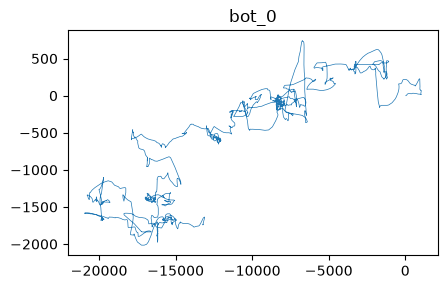


bot_1, events=6135


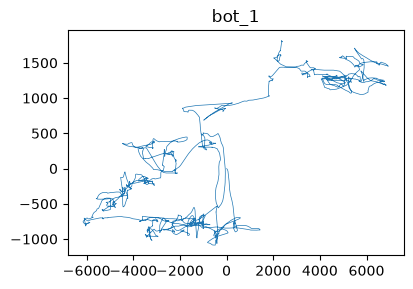


bot_2, events=5624


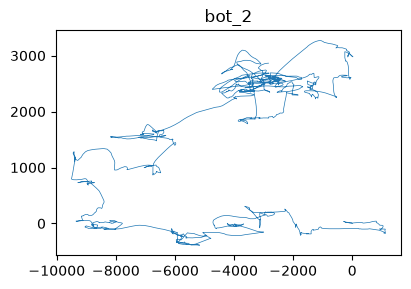


bot_3, events=5627


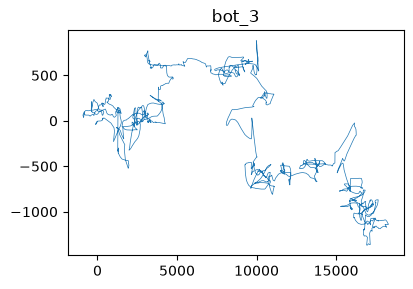


bot_4, events=5624


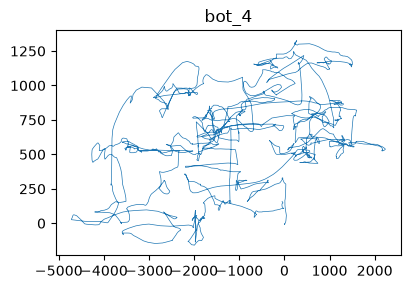

In [23]:
for i, df in enumerate(sample_bot_trajectories):
    df = df.copy()
    df["trajectory_x"] = df["dx"].cumsum()
    df["trajectory_y"] = df["dy"].cumsum()

    print(f"\nbot_{i}, events={len(df)}")

    plt.figure(figsize=(20, 3))

    plt.subplot(1, len(sample_bot_trajectories), i + 1)
    plt.plot(df["trajectory_x"], df["trajectory_y"], linewidth=0.5)
    plt.title(f"bot_{i}")

    plt.tight_layout()
    plt.show()


## Smooth bot generation


In [24]:
def generate_smooth_bot_game(
    n_events=5800,
    dt_mean=17,
    segment_len_range=(20, 60),
    base_speed_range=(5, 25),
    jitter=1.5,
    seed=None,
):
    """Smooth-segment bot: each segment moves in one direction, then switches."""
    rng = np.random.default_rng(seed)

    dxs, dys, times = [], [], []
    current_time = 0
    events_done = 0

    while events_done < n_events:
        angle = rng.uniform(0, 2 * np.pi)
        speed = rng.uniform(*base_speed_range)
        seg_len = rng.integers(*segment_len_range)

        base_dx = np.cos(angle) * speed
        base_dy = np.sin(angle) * speed

        for _ in range(seg_len):
            if events_done >= n_events:
                break

            dx = base_dx + rng.normal(0, jitter)
            dy = base_dy + rng.normal(0, jitter)
            dt = max(1, int(rng.normal(dt_mean, 2)))
            current_time += dt

            dxs.append(round(dx))
            dys.append(round(dy))
            times.append(current_time)
            events_done += 1

    return pd.DataFrame({"dx": dxs, "dy": dys, "time": times})


def estimate_smooth_params(human_df):
    """Derive smooth-bot scale from a game's own human features.
    Keeps the bot mechanical (low jitter, regular dt) but at the game's
    real speed/timing scale, so each game gets its own smooth bot.
    """
    dt_mean = float(human_df["mean_dt"].median())
    avg_speed = float(human_df["avg_speed"].median())
    # feature speed = per-event displacement / dt  ->  base = avg_speed * dt
    base = avg_speed * dt_mean
    return {
        "dt_mean": dt_mean,
        "base_speed_range": (base * 0.5, base * 1.5),
        "jitter": max(0.5, base * 0.1),  # ~10% keeps it mechanical
    }

median_events = int(games_df["n_events"].median())
N_SMOOTH_BOTS = len(games_df)

re_smooth_params = estimate_smooth_params(games_df)
print(f"RE smooth params: {re_smooth_params}")

smooth_rows = []
sample_smooth_trajectories = []
for i in range(N_SMOOTH_BOTS):
    bot_mouse = generate_smooth_bot_game(n_events=median_events, seed=RNG_SEED + i, **re_smooth_params)
    if len(sample_smooth_trajectories) < N_PREVIEW:
        sample_smooth_trajectories.append(bot_mouse.copy())

    feats = extract_features(bot_mouse)
    if feats is None:
        continue
    feats.update({
        "userId": -2,
        "gameId": f"smooth_{i}",
        "source_file": f"synthetic_smooth_{i}",
        "is_bot": 1,
        "bot_type": "smooth",
    })
    smooth_rows.append(feats)

bots_smooth_df = pd.DataFrame(smooth_rows)
print(f"Generated {len(bots_smooth_df)} smooth bot games (n_events={median_events})")
print(bots_smooth_df.head())


RE smooth params: {'dt_mean': 30.881114469487507, 'base_speed_range': (15.567130476433316, 46.701391429299946), 'jitter': 3.1134260952866635}
Generated 476 smooth bot games (n_events=5801)
   total_movement  avg_speed  n_events    mean_dt  idle_ratio  avg_turn_angle  \
0   188952.006590   1.076465      5801  30.395517         0.0        0.299926   
1   185421.004408   1.056772      5801  30.380690         0.0        0.248266   
2   185299.679676   1.056245      5801  30.372241         0.0        0.302256   
3   184912.138112   1.053942      5801  30.385345         0.0        0.227597   
4   175458.179142   0.997179      5801  30.461207         0.0        0.328791   

   speed_std  speed_max  dist_std  userId    gameId         source_file  \
0   0.305241   2.228680  8.940363      -2  smooth_0  synthetic_smooth_0   
1   0.331153   2.015106  9.773787      -2  smooth_1  synthetic_smooth_1   
2   0.336686   2.021155  9.954963      -2  smooth_2  synthetic_smooth_2   
3   0.308863   1.992332 

## Smooth bot trajectory preview



smooth_0, events=5801


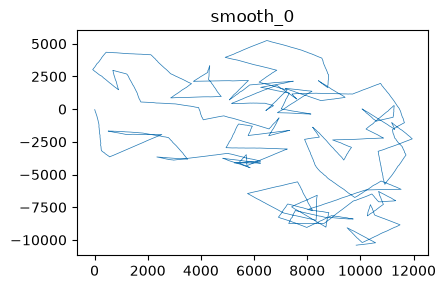


smooth_1, events=5801


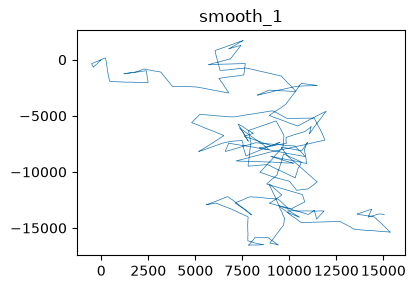


smooth_2, events=5801


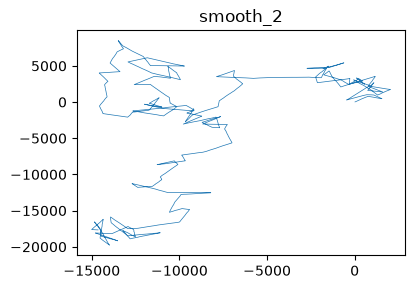


smooth_3, events=5801


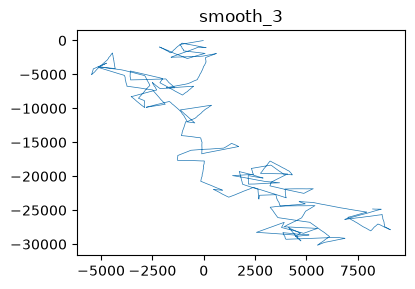


smooth_4, events=5801


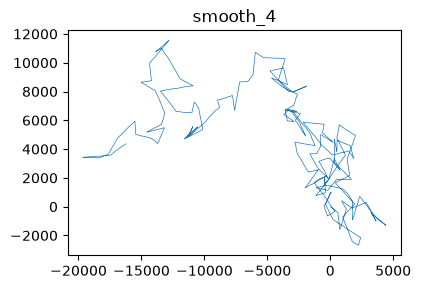

In [25]:
for i, df in enumerate(sample_smooth_trajectories):
    df = df.copy()
    df["trajectory_x"] = df["dx"].cumsum()
    df["trajectory_y"] = df["dy"].cumsum()

    print(f"\nsmooth_{i}, events={len(df)}")
    plt.figure(figsize=(20, 3))
    plt.subplot(1, len(sample_smooth_trajectories), i + 1)
    plt.plot(df["trajectory_x"], df["trajectory_y"], linewidth=0.5)
    plt.title(f"smooth_{i}")

    plt.tight_layout()
    plt.show()


## Shared classifier helper

In [26]:
def eval_human_vs_bot(human_df, bot_df, bot_name):
    """Train/eval one Human vs Bot model. Same features + same classifier for fair comparison."""
    bot_df = bot_df.copy()
    bot_df["is_bot"] = 1

    dataset = pd.concat([human_df, bot_df], ignore_index=True)
    input_data = dataset[feature_cols]
    output_data = dataset["is_bot"]

    input_train, input_test, output_train, output_test = train_test_split(
        input_data, output_data, test_size=0.2, random_state=42, stratify=output_data
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(input_train, output_train)
    output_pred = model.predict(input_test)
    acc = accuracy_score(output_test, output_pred)

    print(f"=== {bot_name} bot ===")
    print(f"Accuracy: {acc:.2%}  (baseline 50%)")
    print(classification_report(output_test, output_pred, target_names=["human", "bot"]))
    return acc


## Human vs Bot classification


In [27]:
acc_stitch = eval_human_vs_bot(games_df, bots_stitch_df, "stitch")
acc_smooth = eval_human_vs_bot(games_df, bots_smooth_df, "smooth")

print("Bot detection difficulty (higher = easier to catch)")
print(f"  stitch: {acc_stitch:.2%}")
print(f"  smooth: {acc_smooth:.2%}")


=== stitch bot ===
Accuracy: 85.34%  (baseline 50%)
              precision    recall  f1-score   support

       human       0.86      0.84      0.85        96
         bot       0.85      0.86      0.85        95

    accuracy                           0.85       191
   macro avg       0.85      0.85      0.85       191
weighted avg       0.85      0.85      0.85       191

=== smooth bot ===
Accuracy: 100.00%  (baseline 50%)
              precision    recall  f1-score   support

       human       1.00      1.00      1.00        96
         bot       1.00      1.00      1.00        95

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191

Bot detection difficulty (higher = easier to catch)
  stitch: 85.34%
  smooth: 100.00%
